# Analysis of Covariance (ANCOVA)

Analysis of covariance (ANCOVA) is a general linear model which blends ANOVA and regression. ANCOVA evaluates whether the means of a dependent variable (dv) are equal across levels of a categorical independent variable (between) often called a treatment, while statistically controlling for the effects of other continuous variables that are not of primary interest, known as covariates or nuisance variables (covar).

Pingouin uses statsmodels.regression.linear_model.OLS to compute the ANCOVA.

## Get info about subjects

In [53]:
from IPython.display import display, Image

STATIC_RENDERING = True


# This is a static rendering of the notebook.
def show_figure(fig):
    if STATIC_RENDERING:
        img = fig.to_image(format="png")
        display(Image(img))
    else:
        fig.show()


In [54]:
# %load_ext cudf.pandas
import pandas as pd
from IPython.display import display
import os
from tqdm import tqdm
from pathlib import Path

import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*column_view.*")

root_dir = os.path.dirname(os.getcwd())  # Use current working directory as root_dir
display("Running in root dir: ", os.path.basename(root_dir))
stats_dir = Path(root_dir) / "stats_QCed" / "sampled"
print("Stats directory:", stats_dir)

output_dir = Path() / "ancova"
output_dir.mkdir(parents=True, exist_ok=True)
print("Output directory:", output_dir.absolute())


'Running in root dir: '

'freesurfer-fuzzy'

Stats directory: /mnt/lustre/ychatel/living-park/VIP-python-client/example/freesurfer-fuzzy/stats_QCed/sampled
Output directory: /mnt/lustre/ychatel/living-park/VIP-python-client/example/freesurfer-fuzzy/notebooks/ancova


In [55]:
def get_cohort_stat():
    df_cohort = pd.read_csv("../cohort_stat.csv")
    print(f"Load cohort stats: {os.path.abspath('../cohort_stat.csv')}")
    columns = [
        "PATNO",
        "first_visit",
        "second_visit",
        "dx_group",
        "SEX",
        "AGE_AT_VISIT",
        "durationT2_T1_y",
    ]
    df_cohort["first_visit"] = (
        "sub-"
        + df_cohort["PATNO"].astype(str)
        + "_ses-"
        + df_cohort["EVENT_ID"].astype(str)
    )
    df_cohort["second_visit"] = (
        "sub-"
        + df_cohort["PATNO"].astype(str)
        + "_ses-"
        + df_cohort["NEXT_VISIT"].astype(str)
    )
    # Remove PD-MCI subjects
    df_cohort = df_cohort[df_cohort["dx_group"] != "PD-MCI"]
    print(f"Number of PD-non-MCI subjects: {df_cohort.shape[0]}")
    return df_cohort[columns]


df_cohort = get_cohort_stat()


Load cohort stats: /mnt/lustre/ychatel/living-park/VIP-python-client/example/freesurfer-fuzzy/cohort_stat.csv
Number of PD-non-MCI subjects: 270


In [56]:
def assert_number_of_repetitions(df, hemisphere=None, repetitions=26):
    """
    Assert that each subjects/region has exactly N repetitions.
    """
    groups = ["subjects", "region"] + (["hemisphere"] if hemisphere else [])
    grouped = df.groupby(groups).count() == repetitions
    assert grouped.all().all(), (
        f"Not all subjects/regions have {repetitions} repetitions. {grouped[grouped == False].count()}"
    )

## Code
### Create baseline dataframe

In [57]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import warnings
from pathlib import Path
import pingouin as pg

warnings.filterwarnings("ignore")


def get_visit_at_metric_df(metric, visit, hemisphere, cohort_df, force=False):
    """
    Get baseline dataframe for a specific metric with enhanced performance and error handling.

    Parameters:
    -----------
    metric : str
        The name of the metric to retrieve
    hemisphere : bool
        Whether to include hemisphere information
    cohort_df : pandas.DataFrame
        Clinical cohort dataframe
    force : bool, default=False
        If True, regenerate the dataframe even if it exists on disk

    Returns:
    --------
    pd.DataFrame
        A dataframe containing the metric values and associated data
    """
    try:
        # Validate visit parameter
        if visit not in [1, 2]:
            raise ValueError("Visit must be 1 or 2")

        # Determine visit name
        visit_name = "baseline" if visit == 1 else "longitudinal"

        # Check for cached file first
        os.makedirs(output_dir, exist_ok=True)
        filename = (
            output_dir / f"ancova_longitudinal_visit-{visit_name}_df_{metric}.parquet"
        )

        if os.path.exists(filename) and not force:
            print(f"📁 Loading cached baseline data for {metric}...")
            df = pd.read_parquet(filename)
            return df

        print(f"🔄 Creating visit-{visit_name} dataframe for {metric}...")

        # Load and process data with error handling
        df = pd.read_parquet(stats_dir / f"{metric}.parquet")

        # Drop column if it exists
        if "PATNO_id" in df.columns:
            df = df.drop(columns=["PATNO_id"])
        if hemisphere:
            df.rename(columns={"hemi": "hemisphere"}, inplace=True)

        # Optimize repetition numbering
        print("🔄 Optimizing repetition numbering...")
        df["repetition"] = (
            df.groupby(["subjects"] + (["hemisphere"] if hemisphere else [])).cumcount()
            + 1
        )

        # Melt operation to reshape dataframe
        print(f"🔄 Reshaping data for {len(df)} records...")

        # Define ID columns based on hemisphere flag
        id_vars = ["repetition", "subjects", "dx_group", "PD_status"] + (
            ["hemisphere"] if hemisphere else []
        )
        df = df.melt(id_vars=id_vars, var_name="region", value_name=metric)

        # Clean region names
        df["region"] = df["region"].str.replace(f"_{metric}", "", regex=False)

        assert_number_of_repetitions(df, hemisphere=hemisphere)

        # Merge with clinical data (for ANCOVA we need age, sex for covariates, and group info)
        print("🔄 Merging with clinical data...")
        visit_col = "first_visit" if visit == 1 else "second_visit"
        clinical_columns = [
            visit_col,
            "AGE_AT_VISIT",
            "SEX",
            "durationT2_T1_y",
        ]

        merged_df = pd.merge(
            df,
            cohort_df[clinical_columns],
            left_on="subjects",
            right_on=visit_col,
            how="inner",
        )

        print(f"✅ Successfully merged {len(merged_df)} clinical records")

        # Clean up data types
        numeric_cols = [metric, "AGE_AT_VISIT", "durationT2_T1_y"]
        for col in numeric_cols:
            if col in merged_df.columns:
                merged_df[col] = pd.to_numeric(merged_df[col], errors="coerce")

        # Save results
        print(f"💾 Saving visit-{visit_name} dataframe to {filename}...")
        merged_df.to_parquet(filename)

        print(f"✅ Created visit-{visit_name} dataframe with {len(merged_df)} records")
        return merged_df

    except Exception as e:
        print(f"❌ Error creating visit-{visit_name} dataframe: {e}")
        raise


def compute_ancova(change_df, metric, hemisphere, force=False):
    """
    Compute ANCOVA with enhanced error handling and performance.

    Parameters:
    -----------
    change_df : pandas.DataFrame
        Dataframe with metric values of change between visits
    metric : str
        The metric name
    hemisphere : bool
        Whether hemisphere information is included
    force : bool, default=False
        Force recomputation even if cached file exists

    Returns:
    --------
    pandas.DataFrame
        ANCOVA results
    """
    try:
        # Check for cached results
        os.makedirs(output_dir, exist_ok=True)
        filename = output_dir / f"ancova_longitudinal_{metric}.parquet"
        if os.path.exists(filename) and not force:
            print(f"📁 Loading cached ANCOVA results for {metric}...")
            df = pd.read_parquet(filename)
            if hasattr(df, "to_pandas"):
                df = df.to_pandas()
            return df

        print(f"🧮 Computing ANCOVA for {metric}...")

        # Validate required columns
        required_cols = [
            f"{metric}_change",
            "dx_group",
            "AGE_AT_VISIT",
            "SEX",
            "repetition",
            "region",
            "durationT2_T1_y",
        ]
        if hemisphere:
            required_cols.append("hemisphere")

        missing_cols = [col for col in required_cols if col not in change_df.columns]
        if missing_cols:
            raise ValueError(f"Missing required columns: {missing_cols}")

        # Set up result dataframe
        if hemisphere:
            columns = ["repetition", "region", "hemisphere", "F", "p-unc", "np2", "n"]
        else:
            columns = ["repetition", "region", "F", "p-unc", "np2", "n"]

        results = []
        errors = []

        # Get unique combinations for processing
        hemispheres = change_df["hemisphere"].unique() if hemisphere else [None]
        repetitions = sorted(change_df["repetition"].unique())
        regions = change_df["region"].unique()

        total_combinations = len(repetitions) * len(regions) * len(hemispheres)
        print(f"📊 Processing {total_combinations} combinations...")

        # Check for variance in covariates
        covariate_cols = ["AGE_AT_VISIT", "SEX", "durationT2_T1_y"]

        # Process with progress bar
        with tqdm(total=total_combinations, desc="Computing ANCOVA") as pbar:
            for rep in repetitions:
                for region in regions:
                    for hemi in hemispheres:
                        try:
                            # Filter data
                            if hemisphere and hemi is not None:
                                data = change_df[
                                    (change_df["repetition"] == rep)
                                    & (change_df["region"] == region)
                                    & (change_df["hemisphere"] == hemi)
                                ]
                            else:
                                data = change_df[
                                    (change_df["repetition"] == rep)
                                    & (change_df["region"] == region)
                                ]

                            # Remove rows with missing values and ensure pandas DataFrame
                            analysis_data = (
                                data[[f"{metric}_change", "dx_group"] + covariate_cols]
                                .dropna()
                                .copy()
                            )

                            if len(analysis_data["dx_group"].unique()) < 2:
                                raise ValueError("Need at least 2 groups for ANCOVA")

                            # Check covariate variance
                            for cov in covariate_cols:
                                if analysis_data[cov].nunique() < 2:
                                    raise ValueError(f"No variance in covariate {cov}")

                            # Ensure proper data types
                            analysis_data[f"{metric}_change"] = pd.to_numeric(
                                analysis_data[f"{metric}_change"], errors="coerce"
                            )
                            analysis_data["AGE_AT_VISIT"] = pd.to_numeric(
                                analysis_data["AGE_AT_VISIT"], errors="coerce"
                            )
                            analysis_data["SEX"] = pd.to_numeric(
                                analysis_data["SEX"], errors="coerce"
                            )
                            analysis_data["dx_group"] = analysis_data[
                                "dx_group"
                            ].astype(str)

                            # Remove any rows that became NaN after conversion
                            analysis_data = analysis_data.dropna()

                            ancova_result = pg.ancova(
                                data=analysis_data,
                                dv=f"{metric}_change",
                                between="dx_group",
                                covar=covariate_cols,
                            )

                            # Extract results for the group effect
                            group_row = ancova_result[
                                ancova_result["Source"] == "dx_group"
                            ]

                            F = float(group_row["F"].iloc[0])
                            pval = float(group_row["p-unc"].iloc[0])
                            np2 = float(group_row["np2"].iloc[0])
                            n = len(analysis_data)

                            # Store result
                            if hemisphere and hemi is not None:
                                results.append([rep, region, hemi, F, pval, np2, n])
                            else:
                                results.append([rep, region, F, pval, np2, n])

                        except Exception as e:
                            error_msg = f"Error: rep={rep}, region={region}, hemi={hemi}: {str(e)}"
                            errors.append(error_msg)

                        pbar.update(1)

        # Create results dataframe
        if results:
            ancova_df = pd.DataFrame(results, columns=columns)
            print(f"✅ Computed {len(ancova_df)} ANCOVA tests")
        else:
            ancova_df = pd.DataFrame(columns=columns)
            print("⚠️  No valid ANCOVA computed")

        # Report errors if any
        if errors:
            print(f"⚠️  {len(errors)} errors encountered:")
            for error in errors[:5]:  # Show first 5 errors
                print(f"   {error}")
            if len(errors) > 5:
                print(f"   ... and {len(errors) - 5} more errors")

        # Save results
        ancova_df.to_parquet(filename)
        print(f"💾 Saved results to {filename}")

        return ancova_df

    except Exception as e:
        print(f"❌ Error computing ANCOVA: {e}")
        raise


def compute_significance(
    ancova_df, hemisphere=False, alpha=0.05, correction_method=None
):
    """
    Compute enhanced significance statistics for ANCOVA results.

    Parameters:
    -----------
    ancova_df : pandas.DataFrame
        The ANCOVA results dataframe
    hemisphere : bool, default=False
        Whether the data includes hemisphere information
    alpha : float, default=0.05
        Significance threshold for p-values
    correction_method : str or None, default=None
        Multiple comparison correction: 'bonferroni', 'fdr_bh', 'fdr_by', or None

    Returns:
    --------
    pandas.DataFrame
        Enhanced significance statistics per region
    """
    try:
        print(
            f"📊 Computing significance statistics for {len(ancova_df)} ANCOVA tests..."
        )

        # Convert cuDF to pandas if needed
        if hasattr(ancova_df, "to_pandas"):
            ancova_df = ancova_df.to_pandas()

        if ancova_df.empty:
            print("⚠️  Empty ANCOVA dataframe")
            return pd.DataFrame()

        # Create working copy
        df_work = ancova_df.copy()

        # Apply multiple comparison correction if requested
        if correction_method is not None:
            df_work = apply_multiple_comparison_correction_ancova(
                df_work, correction_method, alpha
            )
            p_col = "p_corrected"
        else:
            p_col = "p-unc"

        # Add significance indicators
        print("🔄 Adding significance indicators...")
        df_work["significant"] = df_work[p_col] < alpha

        # Determine grouping columns
        group_cols = ["region"]
        if hemisphere:
            group_cols.append("hemisphere")

        # Comprehensive aggregations
        aggregations = {
            "significant": ["sum", "mean"],  # Count and proportion significant
            "F": ["count", "mean", "std", "min", "max"],  # F-statistic summary
            p_col: ["mean", "std", "min", "max"],  # p-value summary
            "np2": ["mean", "std", "min", "max"],  # Eta-squared summary
            "n": ["mean", "min", "max"],  # Sample size summary
        }

        # Compute aggregations
        result = df_work.groupby(group_cols).agg(aggregations).reset_index()

        # Flatten multi-level columns
        result.columns = [
            "_".join(col).strip("_") if col[1] else col[0]
            for col in result.columns.values
        ]

        # Rename columns for clarity
        rename_map = {
            "significant_sum": "n_significant",
            "significant_mean": "proportion_significant",
            "F_count": "n_correlations",  # Keep this name for compatibility
            "F_mean": "mean_F",
            "F_std": "std_F",
            "F_min": "min_F",
            "F_max": "max_F",
            f"{p_col}_mean": "mean_p",
            f"{p_col}_std": "std_p",
            f"{p_col}_min": "min_p",
            f"{p_col}_max": "max_p",
            "np2_mean": "mean_np2",
            "np2_std": "std_np2",
            "np2_min": "min_np2",
            "np2_max": "max_np2",
            "n_mean": "mean_n",
            "n_min": "min_n",
            "n_max": "max_n",
        }

        result = result.rename(columns=rename_map)

        # Add effect size interpretation (using eta-squared)
        print("🔄 Categorizing effect sizes...")
        result["effect_size_category"] = categorize_eta_squared_effect_size(
            result["mean_np2"]
        )

        # Add consistency metrics
        result["significance_rate"] = result["proportion_significant"] * 100
        result["correlation_consistency"] = calculate_ancova_consistency(result)

        # Sort by significance rate
        result = result.sort_values("proportion_significant", ascending=False)

        print(f"✅ Computed significance statistics for {len(result)} regions")

        return result

    except Exception as e:
        print(f"❌ Error computing significance statistics: {e}")
        raise


def apply_multiple_comparison_correction_ancova(df, method, alpha):
    """Apply multiple comparison correction for ANCOVA p-values."""
    from scipy.stats import false_discovery_control

    df = df.copy()
    p_values = df["pval"].values
    n_tests = len(p_values)

    if method == "bonferroni":
        df["p_corrected"] = np.minimum(p_values * n_tests, 1.0)
        print(f"Applied Bonferroni correction for {n_tests} tests")

    elif method == "fdr_bh":
        df["p_corrected"] = false_discovery_control(p_values, method="bh")
        print(f"Applied Benjamini-Hochberg FDR correction for {n_tests} tests")

    elif method == "fdr_by":
        df["p_corrected"] = false_discovery_control(p_values, method="by")
        print(f"Applied Benjamini-Yekutieli FDR correction for {n_tests} tests")

    else:
        raise ValueError(f"Unknown correction method: {method}")

    # Report correction impact
    orig_significant = (p_values < alpha).sum()
    corrected_significant = (df["p_corrected"] < alpha).sum()
    print(
        f"Significant tests: {orig_significant} → {corrected_significant} after correction"
    )

    return df


def categorize_eta_squared_effect_size(eta_squared_values):
    """
    Categorize eta-squared values into effect size categories.

    Cohen's conventions for eta-squared (η²):
    - Small: η² = 0.01
    - Medium: η² = 0.06
    - Large: η² = 0.14
    """
    try:
        # Convert to numpy array and handle potential pandas Series
        if hasattr(eta_squared_values, "values"):
            eta_values = eta_squared_values.values
        else:
            eta_values = np.array(eta_squared_values)

        # Handle empty input
        if len(eta_values) == 0:
            return pd.Series([], dtype="category")

        # Convert to float and handle NaN values
        eta_values = eta_values.astype(float)
        eta_values = np.clip(eta_values, 0, 1)  # Ensure valid range [0,1]

        # Create conditions as numpy boolean arrays
        conditions = [
            eta_values < 0.01,
            (eta_values >= 0.01) & (eta_values < 0.06),
            (eta_values >= 0.06) & (eta_values < 0.14),
            eta_values >= 0.14,
        ]

        # Ensure all conditions are proper numpy boolean arrays
        conditions = [np.asarray(cond, dtype=bool) for cond in conditions]

        choices = ["Negligible", "Small", "Medium", "Large"]

        # Use np.select with proper boolean arrays
        effect_labels = np.select(conditions, choices, default="Unknown")

        # Handle NaN values explicitly
        nan_mask = np.isnan(eta_values)
        effect_labels[nan_mask] = "Unknown"

        print(
            f"Categorized {len(effect_labels)} eta-squared values into effect size categories"
        )

        return pd.Series(
            pd.Categorical(
                effect_labels, categories=choices + ["Unknown"], ordered=True
            ),
            index=eta_squared_values.index
            if hasattr(eta_squared_values, "index")
            else None,
        )

    except Exception as e:
        print(f"Error in categorize_eta_squared_effect_size: {e}")
        # Return unknown categories for all inputs
        n_items = (
            len(eta_squared_values) if hasattr(eta_squared_values, "__len__") else 1
        )
        return pd.Series(
            ["Unknown"] * n_items,
            index=eta_squared_values.index
            if hasattr(eta_squared_values, "index")
            else None,
        )


def calculate_ancova_consistency(result_df):
    """Calculate consistency score for ANCOVA results."""
    # Factors indicating consistency:
    # 1. High proportion of significant results
    # 2. Low variability in F-statistics

    prop_sig = result_df["proportion_significant"]

    # Coefficient of variation for F-statistics
    cv_f = result_df["std_F"] / result_df["mean_F"]
    cv_f = cv_f.fillna(0)

    # Consistency score (0-100)
    consistency = (prop_sig * 50) + ((1 - np.minimum(cv_f, 1)) * 50)

    return consistency.round(1)


def report_significance_df(
    metric, hemisphere, cohort_df, alpha=0.05, correction_method=None, force=False
):
    """
    Enhanced version of report_significance_df with comprehensive ANCOVA analysis.

    Parameters:
    -----------
    metric : str
        The metric to analyze
    hemisphere : bool
        Whether to include hemisphere information
    cohort_df : pandas.DataFrame
        Clinical cohort dataframe
    alpha : float, default=0.05
        Significance threshold
    correction_method : str or None, default='fdr_bh'
        Multiple comparison correction method
    force : bool, default=False
        Force recomputation of all steps

    Returns:
    --------
    pandas.DataFrame
        Enhanced significance results
    """
    try:
        print(f"\n🧠 Enhanced ANCOVA Analysis for {metric.upper()}")
        print("=" * 60)

        # Step 1: Get baseline data
        print(f"\n📊 Step 1: Loading baseline data for {metric}...")
        baseline_df = get_visit_at_metric_df(
            metric, visit=1, hemisphere=hemisphere, cohort_df=cohort_df, force=force
        )
        print(f"Loading next visit data for {metric}...")
        next_df = get_visit_at_metric_df(
            metric, visit=2, hemisphere=hemisphere, cohort_df=cohort_df, force=force
        )

        if baseline_df.empty:
            raise ValueError("No baseline data available")
        if next_df.empty:
            raise ValueError("No longitudinal data available")

        baseline_df["PATNO"] = baseline_df["subjects"].str.split("_").str[0]
        next_df["PATNO"] = next_df["subjects"].str.split("_").str[0]

        # Compute change
        columns_to_merge = ["PATNO", "region", "repetition"]
        if hemisphere:
            columns_to_merge.append("hemisphere")

        change_df = pd.merge(
            baseline_df,
            next_df,
            on=columns_to_merge,
            suffixes=("_baseline", "_next"),
        )

        if change_df.empty:
            raise ValueError(
                "No matching records found between baseline and next visit"
            )

        print(f"✅ Merged baseline and next visit data with shape: {change_df.shape}")

        change_df[f"{metric}_change"] = (
            change_df[f"{metric}_next"] - change_df[f"{metric}_baseline"]
        ) / change_df[f"{metric}_baseline"]

        # remove baseline columns
        print(f"✅ Computed change for {metric} with shape: {change_df.shape}")
        change_df.drop(
            columns=change_df.filter(regex="_baseline$").columns, inplace=True
        )

        print("🔄 Renaming columns for clarity...")
        # remove _next suffix
        change_df.rename(columns=lambda x: x.replace("_next", ""), inplace=True)

        print(f"✅ Loaded {len(change_df)} baseline records")

        # Step 2: Compute ANCOVA
        print("\n🧮 Step 2: Computing ANCOVA...")
        ancova_df = compute_ancova(
            change_df, metric, hemisphere=hemisphere, force=force
        )

        if ancova_df.empty:
            raise ValueError("No ANCOVA computed")

        print(f"✅ Computed {len(ancova_df)} ANCOVA tests")

        # Step 3: Compute significance statistics
        print("\n📊 Step 3: Computing significance statistics...")
        significance_df = compute_significance(
            ancova_df,
            hemisphere=hemisphere,
            alpha=alpha,
            correction_method=correction_method,
        )

        if significance_df.empty:
            raise ValueError("No significance results computed")

        print(f"✅ Computed significance for {len(significance_df)} regions")

        # Step 4: Save results
        print("\n💾 Step 4: Saving results...")
        os.makedirs("ancova", exist_ok=True)

        # Save detailed results
        output_file = output_dir / f"ancova_longitudinal_{metric}.csv"
        significance_df.to_csv(output_file, index=False)
        print(f"📁 Saved detailed results to {output_file}")

        # Step 5: Summary statistics
        print("\n📈 Step 5: Summary Statistics")
        print("-" * 30)

        total_regions = len(significance_df)
        significant_regions = len(
            significance_df[significance_df["proportion_significant"] > 0]
        )
        mean_significance_rate = significance_df["significance_rate"].mean()

        print(f"Total regions analyzed: {total_regions}")
        print(f"Regions with significant group effects: {significant_regions}")
        print(f"Mean significance rate: {mean_significance_rate:.1f}%")

        if correction_method:
            print(f"Multiple comparison correction: {correction_method}")

        # Return only regions with significant effects
        result = significance_df[significance_df["proportion_significant"] > 0]
        print(
            f"\n✅ Analysis complete! Found {len(result)} regions with significant group effects"
        )

        return result

    except Exception as e:
        print(f"❌ Error in enhanced ANCOVA analysis: {e}")
        raise


# Usage examples and documentation
"""
Enhanced ANCOVA Analysis

This enhanced version provides:
1. ANCOVA group comparisons with age/sex covariates
2. Multiple comparison corrections
3. Effect size categorization using eta-squared
4. Comprehensive statistical summaries
5. Progress tracking and detailed logging

Usage:
------
# Basic ANCOVA analysis
results = report_significance_df(
    'volume', 
    hemisphere=True, 
    cohort_df=df_clinical,
    alpha=0.05,
    correction_method='fdr_bh'
)

# Show top significant regions
print("Top 5 regions with strongest group effects:")
top_5 = results.head(5)
for idx, row in top_5.iterrows():
    print(f"{row['region']:20} | {row['significance_rate']:5.1f}% | {row['effect_size_category']:10} | F̄={row['mean_F']:.2f}")

# Manual analysis steps
baseline_df = get_baseline_df('thickness', hemisphere=True, cohort_df=df_clinical)
ancova_df = compute_ancova(baseline_df, 'thickness', hemisphere=True)
significance_df = compute_significance(ancova_df, hemisphere=True, correction_method='bonferroni')
""";


'\nEnhanced ANCOVA Analysis\n\nThis enhanced version provides:\n1. ANCOVA group comparisons with age/sex covariates\n2. Multiple comparison corrections\n3. Effect size categorization using eta-squared\n4. Comprehensive statistical summaries\n5. Progress tracking and detailed logging\n\nUsage:\n------\n# Basic ANCOVA analysis\nresults = report_significance_df(\n    \'volume\', \n    hemisphere=True, \n    cohort_df=df_clinical,\n    alpha=0.05,\n    correction_method=\'fdr_bh\'\n)\n\n# Show top significant regions\nprint("Top 5 regions with strongest group effects:")\ntop_5 = results.head(5)\nfor idx, row in top_5.iterrows():\n    print(f"{row[\'region\']:20} | {row[\'significance_rate\']:5.1f}% | {row[\'effect_size_category\']:10} | F̄={row[\'mean_F\']:.2f}")\n\n# Manual analysis steps\nbaseline_df = get_baseline_df(\'thickness\', hemisphere=True, cohort_df=df_clinical)\nancova_df = compute_ancova(baseline_df, \'thickness\', hemisphere=True)\nsignificance_df = compute_significance(anco

In [ ]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np


def create_ancova_heatmap(significance_df, metric, hemisphere=False):
    """
    Create an interactive heatmap of ANCOVA F-statistics.

    Parameters:
    -----------
    significance_df : pandas.DataFrame
        Significance results from ANCOVA analysis
    metric : str
        The metric name for titles
    hemisphere : bool, default=False
        Whether hemisphere data is included

    Returns:
    --------
    plotly.graph_objects.Figure
        Interactive heatmap
    """
    try:
        # Prepare data for heatmap
        if hemisphere:
            # Pivot to get hemisphere comparison
            heatmap_data = significance_df.pivot_table(
                index="region", columns="hemisphere", values="mean_F", fill_value=0
            )

            # Create custom colorscale for F-statistics (0 to high values)
            colorscale = [
                [0.0, "#ffffff"],  # No effect (white)
                [0.2, "#fee08b"],  # Weak effect (light yellow)
                [0.4, "#fd8d3c"],  # Small effect (orange)
                [0.6, "#f03b20"],  # Medium effect (red)
                [0.8, "#bd0026"],  # Large effect (dark red)
                [1.0, "#800026"],  # Very large effect (very dark red)
            ]

            fig = go.Figure(
                data=go.Heatmap(
                    z=heatmap_data.values,
                    x=heatmap_data.columns,
                    y=heatmap_data.index,
                    colorscale=colorscale,
                    zmin=0,
                    zmax=heatmap_data.values.max()
                    if len(heatmap_data.values) > 0
                    else 10,
                    text=np.round(heatmap_data.values, 2),
                    texttemplate="%{text}",
                    textfont={"size": 10},
                    colorbar=dict(title="Mean F-statistic", titleside="right"),
                )
            )

            title = f"ANCOVA F-statistics Heatmap: {metric.title()} vs Group<br><sub>Controlling for Age and Sex</sub>"

        else:
            # Single column for non-hemisphere data
            heatmap_data = significance_df.set_index("region")[["mean_F"]].sort_values(
                "mean_F", ascending=False
            )

            fig = go.Figure(
                data=go.Heatmap(
                    z=heatmap_data["mean_F"].values.reshape(-1, 1),
                    y=heatmap_data.index,
                    x=["F-statistic"],
                    colorscale="Reds",
                    zmin=0,
                    text=np.round(heatmap_data["mean_F"].values, 2).reshape(-1, 1),
                    texttemplate="%{text}",
                    textfont={"size": 12},
                    colorbar=dict(title="Mean F-statistic", titleside="right"),
                )
            )

            title = f"ANCOVA F-statistics: {metric.title()} vs Group<br><sub>Controlling for Age and Sex</sub>"

        fig.update_layout(
            title=title,
            xaxis_title="Hemisphere" if hemisphere else "",
            yaxis_title="Brain Region",
            height=max(400, len(significance_df) * 20),
            font=dict(size=12),
            title_font_size=16,
        )

        return fig

    except Exception as e:
        print(f"Error creating heatmap: {e}")
        return go.Figure()


def create_ancova_scatter_plot(significance_df, metric):
    """
    Create scatter plot of significance rate vs F-statistic strength.

    Parameters:
    -----------
    significance_df : pandas.DataFrame
        Significance results
    metric : str
        Metric name for titles

    Returns:
    --------
    plotly.graph_objects.Figure
        Interactive scatter plot
    """
    try:
        # Prepare data
        df = significance_df.copy()

        # Color by effect size category
        color_map = {
            "Negligible": "#d3d3d3",
            "Small": "#fee08b",
            "Medium": "#fd8d3c",
            "Large": "#bd0026",
        }

        fig = go.Figure()

        for category in ["Negligible", "Small", "Medium", "Large"]:
            subset = df[df["effect_size_category"] == category]
            if len(subset) > 0:
                fig.add_trace(
                    go.Scatter(
                        x=subset["significance_rate"],
                        y=subset["mean_F"],
                        mode="markers",
                        name=f"{category} Effect",
                        marker=dict(
                            color=color_map[category],
                            size=8,
                            opacity=0.7,
                            line=dict(width=1, color="black"),
                        ),
                        text=subset["region"],
                        hovertemplate="<b>%{text}</b><br>"
                        + "Significance Rate: %{x:.1f}%<br>"
                        + "Mean F-statistic: %{y:.2f}<br>"
                        + f"Effect: {category}<br>"
                        + "<extra></extra>",
                    )
                )

        fig.update_layout(
            title=f"F-statistic Strength vs Significance Rate: {metric.title()}<br><sub>ANCOVA with group comparison (controlling for age, sex)</sub>",
            xaxis_title="Significance Rate (%)",
            yaxis_title="Mean F-statistic",
            height=600,
            showlegend=True,
            hovermode="closest",
        )

        # Add reference lines for effect sizes (based on eta-squared)
        # Convert common eta-squared thresholds to approximate F-values
        fig.add_hline(
            y=1.0,
            line_dash="dash",
            line_color="gray",
            annotation_text="Weak Effect (approx.)",
        )
        fig.add_hline(
            y=4.0,
            line_dash="dash",
            line_color="orange",
            annotation_text="Medium Effect (approx.)",
        )
        fig.add_hline(
            y=10.0,
            line_dash="dash",
            line_color="red",
            annotation_text="Large Effect (approx.)",
        )

        return fig

    except Exception as e:
        print(f"Error creating scatter plot: {e}")
        return go.Figure()


def create_ancova_summary_dashboard(significance_df, metric, hemisphere=False):
    """
    Create a comprehensive dashboard summarizing ANCOVA results.

    Parameters:
    -----------
    significance_df : pandas.DataFrame
        Significance results
    metric : str
        Metric name
    hemisphere : bool, default=False
        Whether hemisphere data is included

    Returns:
    --------
    plotly.graph_objects.Figure
        Multi-panel dashboard
    """
    try:
        # Create subplots
        if hemisphere:
            fig = make_subplots(
                rows=2,
                cols=2,
                subplot_titles=(
                    "Top Regions by Significance Rate",
                    "Effect Size Distribution",
                    "F-statistic Consistency",
                    "Hemisphere Comparison",
                ),
                specs=[
                    [{"type": "bar"}, {"type": "pie"}],
                    [{"type": "scatter"}, {"type": "bar"}],
                ],
            )
        else:
            fig = make_subplots(
                rows=2,
                cols=2,
                subplot_titles=(
                    "Top Regions by Significance Rate",
                    "Effect Size Distribution",
                    "F-statistic Consistency",
                    "Eta-squared Distribution",
                ),
                specs=[
                    [{"type": "bar"}, {"type": "pie"}],
                    [{"type": "scatter"}, {"type": "histogram"}],
                ],
            )

        # 1. Top regions bar chart
        top_regions = significance_df.nlargest(10, "significance_rate")
        hemispheres = top_regions["hemisphere"].unique() if hemisphere else [""]
        for hemi in hemispheres:
            regions = (
                top_regions[top_regions["hemisphere"] == hemi]
                if hemisphere
                else top_regions
            )
            fig.add_trace(
                go.Bar(
                    x=regions["significance_rate"],
                    y=regions["region"],
                    orientation="h",
                    name=f"Significance Rate {hemi}",
                ),
                row=1,
                col=1,
            )

        # 2. Effect size pie chart
        effect_counts = significance_df["effect_size_category"].value_counts()
        fig.add_trace(
            go.Pie(
                labels=effect_counts.index,
                values=effect_counts.values,
                name="Effect Sizes",
                textinfo="label+percent",
                insidetextorientation="radial",
            ),
            row=1,
            col=2,
        )

        # 3. Consistency scatter plot
        fig.add_trace(
            go.Scatter(
                x=significance_df["significance_rate"],
                y=significance_df["correlation_consistency"],
                mode="markers",
                marker=dict(
                    color=significance_df["mean_F"],
                    colorscale="Reds",
                    size=8,
                    colorbar=dict(title="Mean F", x=1.15),
                ),
                text=significance_df["region"],
                name="Consistency",
            ),
            row=2,
            col=1,
        )

        # 4. Fourth panel - hemisphere comparison or eta-squared distribution
        if hemisphere:
            # Hemisphere comparison
            hemi_comparison = (
                significance_df.groupby("hemisphere")
                .agg({"significance_rate": "mean", "mean_F": "mean"})
                .reset_index()
            )

            fig.add_trace(
                go.Bar(
                    x=hemi_comparison["hemisphere"],
                    y=hemi_comparison["significance_rate"],
                    marker_color=["lightcoral", "lightblue"],
                    name="Mean Significance Rate",
                ),
                row=2,
                col=2,
            )
        else:
            # Eta-squared histogram
            if "mean_np2" in significance_df.columns:
                fig.add_trace(
                    go.Histogram(
                        x=significance_df["mean_np2"],
                        nbinsx=20,
                        marker_color="lightgreen",
                        name="Eta-squared",
                        histnorm="probability",
                    ),
                    row=2,
                    col=2,
                )

        # Update layout
        fig.update_layout(
            title=f"ANCOVA Analysis Dashboard: {metric.title()}<br><sub>Group comparison (controlling for age, sex)</sub>",
            height=800,
            showlegend=False,
        )

        # Update axes labels
        fig.update_xaxes(title_text="Significance Rate (%)", row=1, col=1)
        fig.update_xaxes(title_text="Significance Rate (%)", row=2, col=1)
        fig.update_yaxes(title_text="Consistency Score", row=2, col=1)

        if hemisphere:
            fig.update_xaxes(title_text="Hemisphere", row=2, col=2)
            fig.update_yaxes(title_text="Mean Significance Rate (%)", row=2, col=2)
        else:
            fig.update_xaxes(title_text="Mean Eta-squared", row=2, col=2)
            fig.update_yaxes(title_text="Count", row=2, col=2)

        return fig

    except Exception as e:
        print(f"Error creating dashboard: {e}")
        return go.Figure()


def create_interactive_ancova_table(significance_df, top_n=20):
    """
    Create an interactive table showing top ANCOVA results.

    Parameters:
    -----------
    significance_df : pandas.DataFrame
        Significance results
    top_n : int, default=20
        Number of top results to show

    Returns:
    --------
    plotly.graph_objects.Figure
        Interactive table
    """
    try:
        # Select top regions and relevant columns
        display_df = significance_df.head(top_n).copy()

        # Format columns for display
        display_df["mean_F_formatted"] = display_df["mean_F"].apply(
            lambda x: f"{x:.2f}"
        )
        display_df["significance_rate_formatted"] = display_df[
            "significance_rate"
        ].apply(lambda x: f"{x:.1f}%")
        display_df["mean_p_formatted"] = display_df["mean_p"].apply(
            lambda x: f"{x:.4f}"
        )
        display_df["consistency_formatted"] = display_df[
            "correlation_consistency"
        ].apply(lambda x: f"{x:.1f}")

        if "mean_np2" in display_df.columns:
            display_df["mean_np2_formatted"] = display_df["mean_np2"].apply(
                lambda x: f"{x:.3f}"
            )

        # Select columns for table
        if "hemisphere" in display_df.columns:
            table_columns = [
                "region",
                "hemisphere",
                "mean_F_formatted",
                "mean_np2_formatted",
                "significance_rate_formatted",
                "effect_size_category",
                "mean_p_formatted",
                "consistency_formatted",
                "n_correlations",
            ]
            column_names = [
                "Region",
                "Hemisphere",
                "Mean F",
                "Mean η²",
                "Significance Rate",
                "Effect Size",
                "Mean p-value",
                "Consistency",
                "N Tests",
            ]
        else:
            table_columns = [
                "region",
                "mean_F_formatted",
                "mean_np2_formatted",
                "significance_rate_formatted",
                "effect_size_category",
                "mean_p_formatted",
                "consistency_formatted",
                "n_correlations",
            ]
            column_names = [
                "Region",
                "Mean F",
                "Mean η²",
                "Significance Rate",
                "Effect Size",
                "Mean p-value",
                "Consistency",
                "N Tests",
            ]

        # Create color coding for F-statistic strength
        colors = []
        for f_val in display_df["mean_F"]:
            if f_val >= 10:
                colors.append("#bd0026")  # Large - dark red
            elif f_val >= 4:
                colors.append("#f03b20")  # Medium - red
            elif f_val >= 1:
                colors.append("#fd8d3c")  # Small - orange
            else:
                colors.append("#f0f0f0")  # Negligible - light gray

        fig = go.Figure(
            data=[
                go.Table(
                    header=dict(
                        values=column_names,
                        fill_color="steelblue",
                        font=dict(color="white", size=12),
                        align="center",
                    ),
                    cells=dict(
                        values=[display_df[col] for col in table_columns],
                        fill_color=[
                            colors if col == "mean_F_formatted" else "white"
                            for col in table_columns
                        ],
                        align="center",
                        font=dict(size=11),
                    ),
                )
            ]
        )

        fig.update_layout(
            title=f"Top {top_n} Regions by Significance Rate<br><sub>ANCOVA results (controlling for age, sex)</sub>",
            height=600,
        )

        return fig

    except Exception as e:
        print(f"Error creating table: {e}")
        return go.Figure()


def summarize_ancova_results(significance_df):
    """
    Generate a comprehensive text summary of ANCOVA results.

    Parameters:
    -----------
    significance_df : pandas.DataFrame
        Significance results

    Returns:
    --------
    dict
        Summary statistics and interpretations
    """
    try:
        summary = {}

        # Basic statistics
        summary["total_regions"] = len(significance_df)
        summary["regions_with_significant_effects"] = len(
            significance_df[significance_df["proportion_significant"] > 0]
        )
        summary["mean_significance_rate"] = significance_df["significance_rate"].mean()
        summary["median_F_statistic"] = significance_df["mean_F"].median()

        # Effect size distribution
        effect_dist = (
            significance_df["effect_size_category"].value_counts(normalize=True) * 100
        )
        summary["effect_size_distribution"] = effect_dist.to_dict()

        # Top regions
        top_5 = significance_df.head(5)
        summary["top_regions"] = [
            {
                "region": row["region"],
                "hemisphere": row.get("hemisphere", "N/A"),
                "significance_rate": row["significance_rate"],
                "mean_F": row["mean_F"],
                "effect_size": row["effect_size_category"],
            }
            for _, row in top_5.iterrows()
        ]

        # F-statistic strength summary
        large_effects = len(significance_df[significance_df["mean_F"] >= 10])
        medium_effects = len(
            significance_df[
                (significance_df["mean_F"] >= 4) & (significance_df["mean_F"] < 10)
            ]
        )
        summary["large_effects"] = large_effects
        summary["medium_effects"] = medium_effects

        return summary

    except Exception as e:
        print(f"Error creating summary: {e}")
        return {}


def generate_ancova_report(significance_df, metric, output_file=None):
    """
    Generate a comprehensive text report of ANCOVA analysis.

    Parameters:
    -----------
    significance_df : pandas.DataFrame
        Significance results
    metric : str
        Metric name
    output_file : str, optional
        File path to save the report

    Returns:
    --------
    str
        Formatted report text
    """
    try:
        summary = summarize_ancova_results(significance_df)

        report = f"""
ANCOVA ANALYSIS REPORT
{"=" * 50}

Metric: {metric.title()}
Analysis: ANCOVA comparing groups (controlling for age and sex)
Date: {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")}

SUMMARY STATISTICS
{"-" * 20}
• Total brain regions analyzed: {summary["total_regions"]}
• Regions with significant group effects: {summary["regions_with_significant_effects"]}
• Overall significance rate: {summary["mean_significance_rate"]:.1f}%
• Median F-statistic: {summary["median_F_statistic"]:.2f}

EFFECT SIZE DISTRIBUTION
{"-" * 24}
"""

        for effect, percentage in summary["effect_size_distribution"].items():
            report += f"• {effect}: {percentage:.1f}%\n"

        report += f"""
GROUP EFFECT PATTERNS
{"-" * 20}
• Large group effects (F ≥ 10.0): {summary["large_effects"]} regions
• Medium group effects (4.0 ≤ F < 10.0): {summary["medium_effects"]} regions

TOP 5 MOST SIGNIFICANT REGIONS
{"-" * 34}
"""

        for i, region in enumerate(summary["top_regions"], 1):
            hemi_str = (
                f" ({region['hemisphere']})" if region["hemisphere"] != "N/A" else ""
            )
            report += f"{i}. {region['region']}{hemi_str}\n"
            report += f"   • Significance rate: {region['significance_rate']:.1f}%\n"
            report += f"   • Mean F-statistic: {region['mean_F']:.2f}\n"
            report += f"   • Effect size: {region['effect_size']}\n\n"

        report += f"""
INTERPRETATION
{"-" * 14}
The ANCOVA analysis reveals group differences in {metric} while controlling for age and sex.
These results help identify brain regions where structural differences between groups are most
consistent and statistically significant.

Regions with high significance rates show consistent group differences across multiple repetitions,
suggesting robust effects that are less likely to be due to random variation.

Effect sizes follow standard conventions for eta-squared (η²):
• Small effect (η² ≥ 0.01): Detectable group difference
• Medium effect (η² ≥ 0.06): Moderate clinical relevance  
• Large effect (η² ≥ 0.14): Strong clinical significance

F-statistics represent the ratio of between-group to within-group variance:
• Higher F-values indicate stronger group differences
• Statistical significance depends on both effect size and sample size

NOTES
{"-" * 5}
• ANCOVA controls for confounding effects of age and sex
• Results are based on repeated measures to assess consistency
• Multiple comparison corrections may be applied to control false discovery rate
• Interpretation should consider clinical context and study limitations
"""

        if output_file:
            with open(output_file, "w") as f:
                f.write(report)
            print(f"📁 Report saved to {output_file}")

        return report

    except Exception as e:
        print(f"Error generating report: {e}")
        return f"Error generating report: {e}"


# Usage examples
"""
# Create visualizations for ANCOVA results
significance_results = report_significance_df('volume', hemisphere=True, cohort_df=df_clinical)

# 1. ANCOVA F-statistics heatmap
heatmap_fig = create_ancova_heatmap(significance_results, 'volume', hemisphere=True)
heatmap_fig.show()

# 2. Scatter plot of F-statistic strength vs significance
scatter_fig = create_ancova_scatter_plot(significance_results, 'volume')
scatter_fig.show()

# 3. Comprehensive dashboard
dashboard_fig = create_ancova_summary_dashboard(significance_results, 'volume', hemisphere=True)
dashboard_fig.show()

# 4. Interactive table
table_fig = create_interactive_ancova_table(significance_results, top_n=15)
table_fig.show()

# 5. Generate text report
report = generate_ancova_report(significance_results, 'volume', 'volume_ancova_report.txt')
print(report)

# 6. Summary statistics
summary = summarize_ancova_results(significance_results)
print("Summary:", summary)
""";

'\n# Create visualizations for ANCOVA results\nsignificance_results = report_significance_df(\'volume\', hemisphere=True, cohort_df=df_clinical)\n\n# 1. ANCOVA F-statistics heatmap\nheatmap_fig = create_ancova_heatmap(significance_results, \'volume\', hemisphere=True)\nheatmap_fig.show()\n\n# 2. Scatter plot of F-statistic strength vs significance\nscatter_fig = create_ancova_scatter_plot(significance_results, \'volume\')\nscatter_fig.show()\n\n# 3. Comprehensive dashboard\ndashboard_fig = create_ancova_summary_dashboard(significance_results, \'volume\', hemisphere=True)\ndashboard_fig.show()\n\n# 4. Interactive table\ntable_fig = create_interactive_ancova_table(significance_results, top_n=15)\ntable_fig.show()\n\n# 5. Generate text report\nreport = generate_ancova_report(significance_results, \'volume\', \'volume_ancova_report.txt\')\nprint(report)\n\n# 6. Summary statistics\nsummary = summarize_ancova_results(significance_results)\nprint("Summary:", summary)\n'

In [59]:
def run_complete_ancova_analysis(
    metrics,
    cohort_df,
    hemisphere=True,
    alpha=0.05,
    correction_method=None,
    force=False,
    generate_visualizations=True,
    save_report=True,
):
    """
    Run complete enhanced ANCOVA analysis for multiple metrics.

    Parameters:
    -----------
    metrics : list or str
        List of metrics to analyze or single metric name
    cohort_df : pandas.DataFrame
        Clinical cohort dataframe
    hemisphere : bool, default=True
        Whether to include hemisphere information
    alpha : float, default=0.05
        Significance threshold
    correction_method : str or None, default='fdr_bh'
        Multiple comparison correction method
    force : bool, default=False
        Force recomputation of all steps
    generate_visualizations : bool, default=True
        Whether to create and display visualizations
    save_report : bool, default=True
        Whether to save text reports

    Returns:
    --------
    dict
        Dictionary containing results for each metric
    """
    import os
    from IPython.display import display, HTML

    # Ensure metrics is a list
    if isinstance(metrics, str):
        metrics = [metrics]

    results = {}

    print("\n🧠 COMPLETE ANCOVA ANALYSIS")
    print("=" * 60)
    print(f"📊 Analyzing {len(metrics)} metric(s): {', '.join(metrics)}")
    print(f"🎯 Significance threshold: α = {alpha}")
    print(f"🔧 Multiple comparison correction: {correction_method or 'None'}")
    print(f"🌐 Hemisphere analysis: {'Enabled' if hemisphere else 'Disabled'}")
    print("=" * 60)

    for i, metric in enumerate(metrics, 1):
        try:
            print(f"\n🔬 ANALYSIS {i}/{len(metrics)}: {metric.upper()}")
            print("-" * 40)

            # Run enhanced ANCOVA analysis
            significance_df = report_significance_df(
                metric=metric,
                hemisphere=hemisphere,
                cohort_df=cohort_df,
                alpha=alpha,
                correction_method=correction_method,
                force=force,
            )

            if significance_df.empty:
                print(f"⚠️  No significant group effects found for {metric}")
                results[metric] = {
                    "significance_df": significance_df,
                    "summary": {},
                    "visualizations": {},
                    "report": f"No significant group effects found for {metric}",
                }
                continue

            # Store results
            results[metric] = {
                "significance_df": significance_df,
                "summary": {},
                "visualizations": {},
                "report": "",
            }

            # Generate summary
            print(f"\n📈 Generating summary for {metric}...")
            summary = summarize_ancova_results(significance_df)
            results[metric]["summary"] = summary

            # Generate visualizations
            if generate_visualizations:
                print(f"\n📊 Creating visualizations for {metric}...")

                try:
                    # F-statistics heatmap
                    heatmap_fig = create_ancova_heatmap(
                        significance_df, metric, hemisphere
                    )
                    results[metric]["visualizations"]["heatmap"] = heatmap_fig

                    # Scatter plot
                    scatter_fig = create_ancova_scatter_plot(significance_df, metric)
                    results[metric]["visualizations"]["scatter"] = scatter_fig

                    # Dashboard
                    dashboard_fig = create_ancova_summary_dashboard(
                        significance_df, metric, hemisphere
                    )
                    results[metric]["visualizations"]["dashboard"] = dashboard_fig

                    # Interactive table
                    table_fig = create_interactive_ancova_table(
                        significance_df, top_n=20
                    )
                    results[metric]["visualizations"]["table"] = table_fig

                    print(f"✅ Created 4 visualizations for {metric}")

                    # Display key visualizations
                    print(f"\n🎨 Displaying dashboard for {metric}...")
                    show_figure(dashboard_fig)

                    print(f"\n📋 Displaying top results table for {metric}...")
                    show_figure(table_fig)

                except Exception as e:
                    print(f"⚠️  Error creating visualizations for {metric}: {e}")

            # Generate text report
            if save_report:
                print(f"\n📝 Generating report for {metric}...")
                try:
                    reports_dir = output_dir / "reports"
                    os.makedirs(reports_dir, exist_ok=True)
                    report_file = (
                        reports_dir / f"{metric}_ancova_longitudinal_report.txt"
                    )
                    report = generate_ancova_report(
                        significance_df, metric, report_file
                    )
                    results[metric]["report"] = report
                    print(f"✅ Report saved to {report_file}")
                except Exception as e:
                    print(f"⚠️  Error generating report for {metric}: {e}")

            # Print quick summary
            print(f"\n📊 QUICK SUMMARY FOR {metric.upper()}")
            print("-" * 30)
            print(f"Regions analyzed: {summary['total_regions']}")
            print(f"Significant regions: {summary['regions_with_significant_effects']}")
            print(f"Mean significance rate: {summary['mean_significance_rate']:.1f}%")
            print(f"Median F-statistic: {summary['median_F_statistic']:.2f}")

            if summary["top_regions"]:
                top_region = summary["top_regions"][0]
                hemi_str = (
                    f" ({top_region['hemisphere']})"
                    if top_region["hemisphere"] != "N/A"
                    else ""
                )
                print(
                    f"Top region: {top_region['region']}{hemi_str} ({top_region['significance_rate']:.1f}%)"
                )

        except Exception as e:
            print(f"❌ Error analyzing {metric}: {e}")
            results[metric] = {
                "significance_df": pd.DataFrame(),
                "summary": {},
                "visualizations": {},
                "report": f"Error analyzing {metric}: {e}",
            }

    # Generate comparison report if multiple metrics
    if len(metrics) > 1:
        print("\n📊 COMPARATIVE ANALYSIS")
        print("=" * 30)

        comparison_data = []
        for metric, result in results.items():
            summary = result["summary"]
            if summary:
                comparison_data.append(
                    {
                        "Metric": metric.title(),
                        "Regions Analyzed": summary["total_regions"],
                        "Significant Regions": summary[
                            "regions_with_significant_effects"
                        ],
                        "Mean Significance Rate (%)": f"{summary['mean_significance_rate']:.1f}",
                        "Median F-statistic": f"{summary['median_F_statistic']:.2f}",
                    }
                )

        if comparison_data:
            comparison_df = pd.DataFrame(comparison_data)
            print("\nComparative Summary:")
            print(comparison_df.to_string(index=False))

            # Save comparison
            if save_report:
                reports_dir = output_dir / "reports"
                comparison_file = (
                    reports_dir / "ancova_longitudinal_comparative_analysis.csv"
                )
                comparison_df.to_csv(comparison_file, index=False)
                print(f"\n💾 Comparative analysis saved to {comparison_file}")

    print("\n🎉 ANALYSIS COMPLETE!")
    print("-" * 20)
    print(
        f"✅ Successfully analyzed {len([r for r in results.values() if not r['significance_df'].empty])} / {len(metrics)} metrics"
    )
    print("📁 Results saved in ancova/ directory")

    if generate_visualizations:
        print("🎨 Interactive visualizations created and displayed")

    if save_report:
        print("📝 Detailed reports generated")

    return results


# Usage examples
"""
# Custom analysis
custom_results = run_complete_ancova_analysis(
    metrics=['thickness', 'area'],
    cohort_df=df_clinical,
    hemisphere=True,
    alpha=0.01,  # More stringent threshold
    correction_method='bonferroni',  # Conservative correction
    force=True,  # Recompute everything
    generate_visualizations=True,
    save_report=True
)

# Access specific results
volume_significance = custom_results['volume']['significance_df']
volume_heatmap = custom_results['volume']['visualizations']['heatmap']
volume_report = custom_results['volume']['report']

# Display specific visualization
custom_results['thickness']['visualizations']['dashboard'].show()
""";

### Compute partial correlation

### Get significant partial correlation among repetitions

## Cortical volume


🧠 COMPLETE ANCOVA ANALYSIS
📊 Analyzing 1 metric(s): volume
🎯 Significance threshold: α = 0.05
🔧 Multiple comparison correction: None
🌐 Hemisphere analysis: Enabled

🔬 ANALYSIS 1/1: VOLUME
----------------------------------------

🧠 Enhanced ANCOVA Analysis for VOLUME

📊 Step 1: Loading baseline data for volume...
📁 Loading cached baseline data for volume...
Loading next visit data for volume...
📁 Loading cached baseline data for volume...
✅ Merged baseline and next visit data with shape: (475488, 20)
✅ Computed change for volume with shape: (475488, 21)
🔄 Renaming columns for clarity...
✅ Loaded 475488 baseline records

🧮 Step 2: Computing ANCOVA...
📁 Loading cached ANCOVA results for volume...
✅ Computed 1872 ANCOVA tests

📊 Step 3: Computing significance statistics...
📊 Computing significance statistics for 1872 ANCOVA tests...
🔄 Adding significance indicators...
🔄 Categorizing effect sizes...
Categorized 72 eta-squared values into effect size categories
✅ Computed significance stat

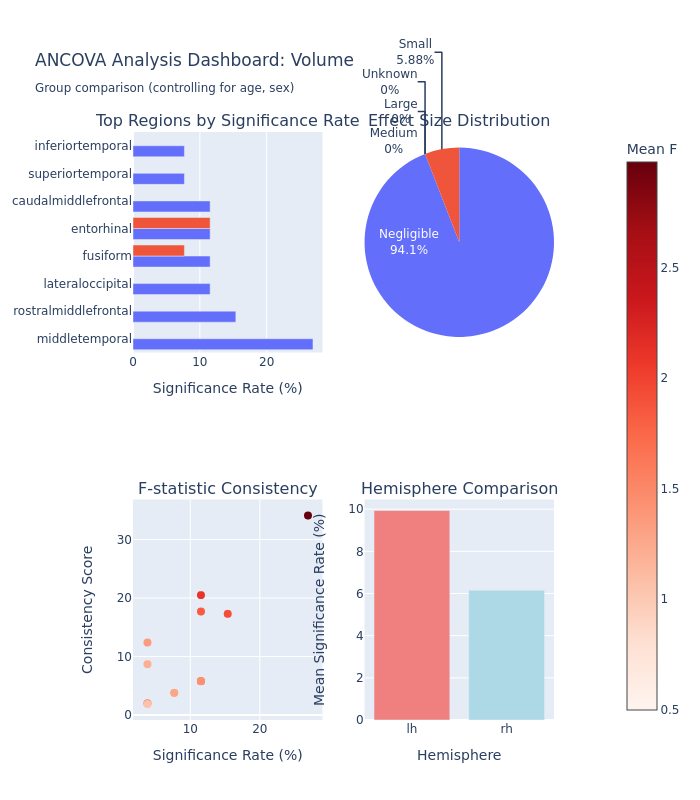


📋 Displaying top results table for volume...


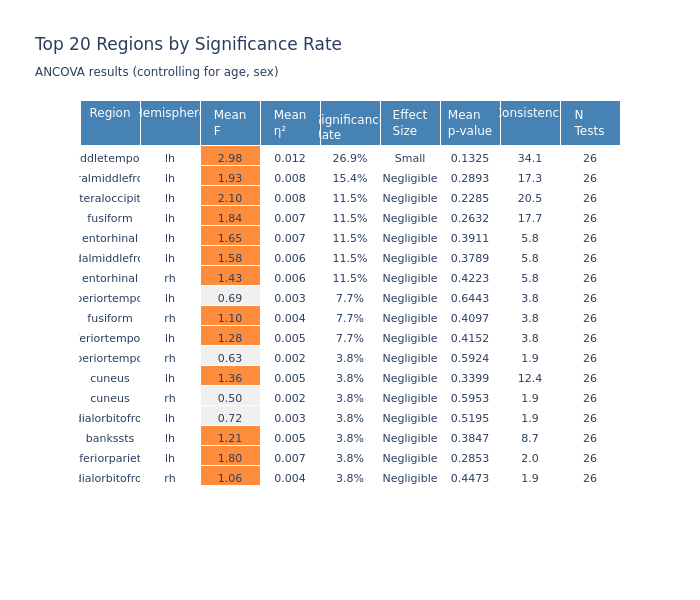


📝 Generating report for volume...
📁 Report saved to ancova/reports/volume_ancova_longitudinal_report.txt
✅ Report saved to ancova/reports/volume_ancova_longitudinal_report.txt

📊 QUICK SUMMARY FOR VOLUME
------------------------------
Regions analyzed: 17
Significant regions: 17
Mean significance rate: 8.8%
Median F-statistic: 1.36
Top region: middletemporal (lh) (26.9%)

🎉 ANALYSIS COMPLETE!
--------------------
✅ Successfully analyzed 1 / 1 metrics
📁 Results saved in ancova/ directory
🎨 Interactive visualizations created and displayed
📝 Detailed reports generated


In [60]:
# Enhanced single metric analysis
volume_results = run_complete_ancova_analysis(
    metrics="volume",
    cohort_df=df_cohort,
    hemisphere=True,
    alpha=0.05,
    correction_method=None,
    force=False,
)

# Access results
significance_volume_df = volume_results["volume"]["significance_df"]
summary_volume = volume_results["volume"]["summary"]
visualizations_volume = volume_results["volume"]["visualizations"]


In [66]:
significance_volume_df


,region,hemisphere,n_significant,proportion_significant,n_correlations,mean_F,std_F,min_F,max_F,mean_p,...,mean_np2,std_np2,min_np2,max_np2,mean_n,min_n,max_n,effect_size_category,significance_rate,correlation_consistency
34,middletemporal,lh,7,0.269231,26,2.979393,1.748134,6.333517e-01,8.547200,0.132481,...,0.011779,0.006798,2.537128e-03,0.033187,254.0,254,254,Small,26.923077,34.1
58,rostralmiddlefrontal,lh,4,0.153846,26,1.927410,1.555677,3.507256e-02,4.834111,0.289342,...,0.007645,0.006132,1.408338e-04,0.019044,254.0,254,254,Negligible,15.384615,17.3
26,lateraloccipital,lh,3,0.115385,26,2.103395,1.482841,1.500969e-01,5.769194,0.228509,...,0.008344,0.005828,6.024358e-04,0.022645,254.0,254,254,Negligible,11.538462,20.5
16,fusiform,lh,3,0.115385,26,1.837863,1.397872,1.314080e-01,5.235274,0.263224,...,0.007297,0.005503,5.274647e-04,0.020592,254.0,254,254,Negligible,11.538462,17.7
12,entorhinal,lh,3,0.115385,26,1.654224,1.727682,2.007709e-08,6.836758,0.391074,...,0.006555,0.006789,8.063088e-11,0.026723,254.0,254,254,Negligible,11.538462,5.8
6,caudalmiddlefrontal,lh,3,0.115385,26,1.584159,1.780985,4.989070e-03,6.912985,0.378943,...,0.006274,0.006990,2.003603e-05,0.027013,254.0,254,254,Negligible,11.538462,5.8
13,entorhinal,rh,3,0.115385,26,1.431859,1.723735,8.267980e-03,6.326925,0.422349,...,0.005673,0.006780,3.320364e-05,0.024780,254.0,254,254,Negligible,11.538462,5.8
64,superiortemporal,lh,2,0.076923,26,0.685228,1.689385,8.238801e-05,8.031761,0.644292,...,0.002701,0.006590,3.308754e-07,0.031248,254.0,254,254,Negligible,7.692308,3.8
17,fusiform,rh,2,0.076923,26,1.095581,1.303783,9.534033e-02,5.355377,0.409661,...,0.004355,0.005132,3.827463e-04,0.021055,254.0,254,254,Negligible,7.692308,3.8
20,inferiortemporal,lh,2,0.076923,26,1.275201,1.391860,6.963350e-02,5.007663,0.415183,...,0.005066,0.005498,2.795744e-04,0.019715,254.0,254,254,Negligible,7.692308,3.8


## Cortical thickness


🧠 COMPLETE ANCOVA ANALYSIS
📊 Analyzing 1 metric(s): thickness
🎯 Significance threshold: α = 0.05
🔧 Multiple comparison correction: None
🌐 Hemisphere analysis: Enabled

🔬 ANALYSIS 1/1: THICKNESS
----------------------------------------

🧠 Enhanced ANCOVA Analysis for THICKNESS

📊 Step 1: Loading baseline data for thickness...
📁 Loading cached baseline data for thickness...
Loading next visit data for thickness...
📁 Loading cached baseline data for thickness...
✅ Merged baseline and next visit data with shape: (488696, 20)
✅ Computed change for thickness with shape: (488696, 21)
🔄 Renaming columns for clarity...
✅ Loaded 488696 baseline records

🧮 Step 2: Computing ANCOVA...
📁 Loading cached ANCOVA results for thickness...
✅ Computed 1924 ANCOVA tests

📊 Step 3: Computing significance statistics...
📊 Computing significance statistics for 1924 ANCOVA tests...
🔄 Adding significance indicators...
🔄 Categorizing effect sizes...
Categorized 74 eta-squared values into effect size categories
✅

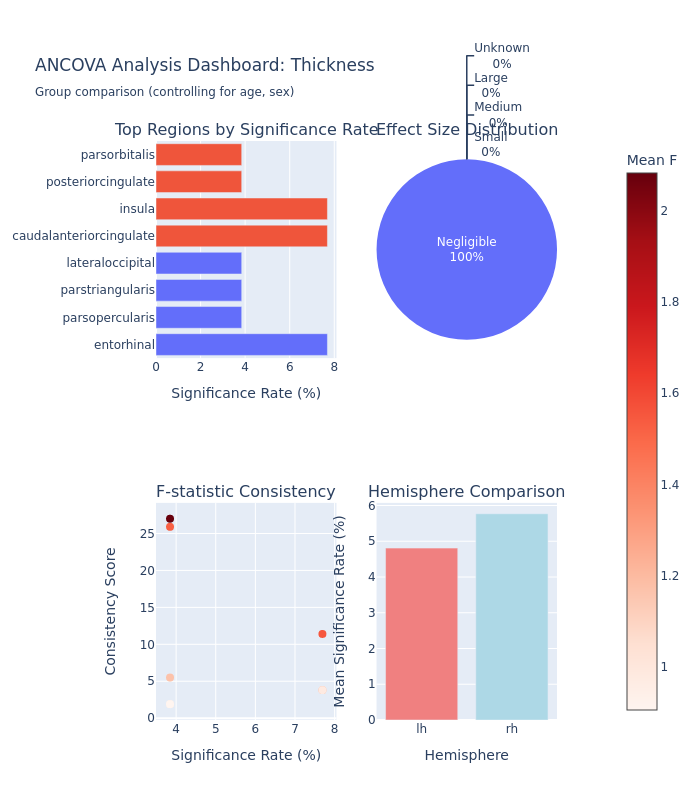


📋 Displaying top results table for thickness...


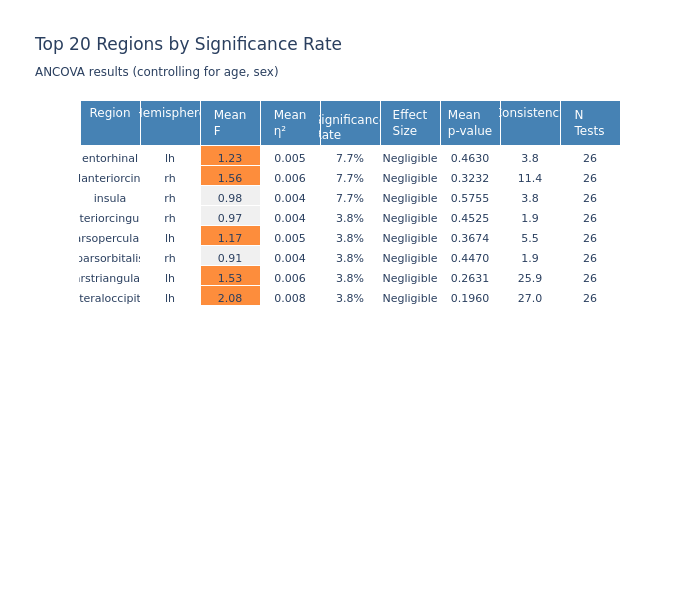


📝 Generating report for thickness...
📁 Report saved to ancova/reports/thickness_ancova_longitudinal_report.txt
✅ Report saved to ancova/reports/thickness_ancova_longitudinal_report.txt

📊 QUICK SUMMARY FOR THICKNESS
------------------------------
Regions analyzed: 8
Significant regions: 8
Mean significance rate: 5.3%
Median F-statistic: 1.20
Top region: entorhinal (lh) (7.7%)

🎉 ANALYSIS COMPLETE!
--------------------
✅ Successfully analyzed 1 / 1 metrics
📁 Results saved in ancova/ directory
🎨 Interactive visualizations created and displayed
📝 Detailed reports generated


In [61]:
# Enhanced single metric analysis
thickness_results = run_complete_ancova_analysis(
    metrics="thickness",
    cohort_df=df_cohort,
    hemisphere=True,
    alpha=0.05,
    correction_method=None,
    force=False,
)

# Access results
significance_thickness_df = thickness_results["thickness"]["significance_df"]
summary_thickness = thickness_results["thickness"]["summary"]
visualizations_thickness = thickness_results["thickness"]["visualizations"]


In [62]:
significance_thickness_df

,region,hemisphere,n_significant,proportion_significant,n_correlations,mean_F,std_F,min_F,max_F,mean_p,...,mean_np2,std_np2,min_np2,max_np2,mean_n,min_n,max_n,effect_size_category,significance_rate,correlation_consistency
14,entorhinal,lh,2,0.076923,26,1.232832,1.515163,0.000542,4.712773,0.462990,...,0.004892,0.005982,2.176861e-06,0.018575,254.0,254,254,Negligible,7.692308,3.8
7,caudalanteriorcingulate,rh,2,0.076923,26,1.557872,1.321005,0.031632,5.086549,0.323225,...,0.006191,0.005213,1.270191e-04,0.020019,254.0,254,254,Negligible,7.692308,11.4
25,insula,rh,2,0.076923,26,0.980286,1.895089,0.000166,8.467487,0.575488,...,0.003868,0.007394,6.660013e-07,0.032888,254.0,254,254,Negligible,7.692308,3.8
53,posteriorcingulate,rh,1,0.038462,26,0.971529,1.127445,0.000446,4.625959,0.452470,...,0.003867,0.004453,1.791796e-06,0.018239,254.0,254,254,Negligible,3.846154,1.9
42,parsopercularis,lh,1,0.038462,26,1.173286,1.088428,0.041497,5.334502,0.367364,...,0.004672,0.004290,1.666273e-04,0.020974,254.0,254,254,Negligible,3.846154,5.5
45,parsorbitalis,rh,1,0.038462,26,0.906142,0.941281,0.069759,3.938758,0.446976,...,0.003612,0.003731,2.800795e-04,0.015572,254.0,254,254,Negligible,3.846154,1.9
46,parstriangularis,lh,1,0.038462,26,1.525447,0.794225,0.016147,4.078641,0.263085,...,0.006079,0.003141,6.484439e-05,0.016116,254.0,254,254,Negligible,3.846154,25.9
28,lateraloccipital,lh,1,0.038462,26,2.081909,1.036500,0.285880,4.468616,0.195975,...,0.008276,0.004090,1.146796e-03,0.017630,254.0,254,254,Negligible,3.846154,27.0


## Cortical surface area


🧠 COMPLETE ANCOVA ANALYSIS
📊 Analyzing 1 metric(s): area
🎯 Significance threshold: α = 0.05
🔧 Multiple comparison correction: None
🌐 Hemisphere analysis: Enabled

🔬 ANALYSIS 1/1: AREA
----------------------------------------

🧠 Enhanced ANCOVA Analysis for AREA

📊 Step 1: Loading baseline data for area...
📁 Loading cached baseline data for area...
Loading next visit data for area...
📁 Loading cached baseline data for area...
✅ Merged baseline and next visit data with shape: (488696, 20)
✅ Computed change for area with shape: (488696, 21)
🔄 Renaming columns for clarity...
✅ Loaded 488696 baseline records

🧮 Step 2: Computing ANCOVA...
📁 Loading cached ANCOVA results for area...
✅ Computed 1924 ANCOVA tests

📊 Step 3: Computing significance statistics...
📊 Computing significance statistics for 1924 ANCOVA tests...
🔄 Adding significance indicators...
🔄 Categorizing effect sizes...
Categorized 74 eta-squared values into effect size categories
✅ Computed significance statistics for 74 regi

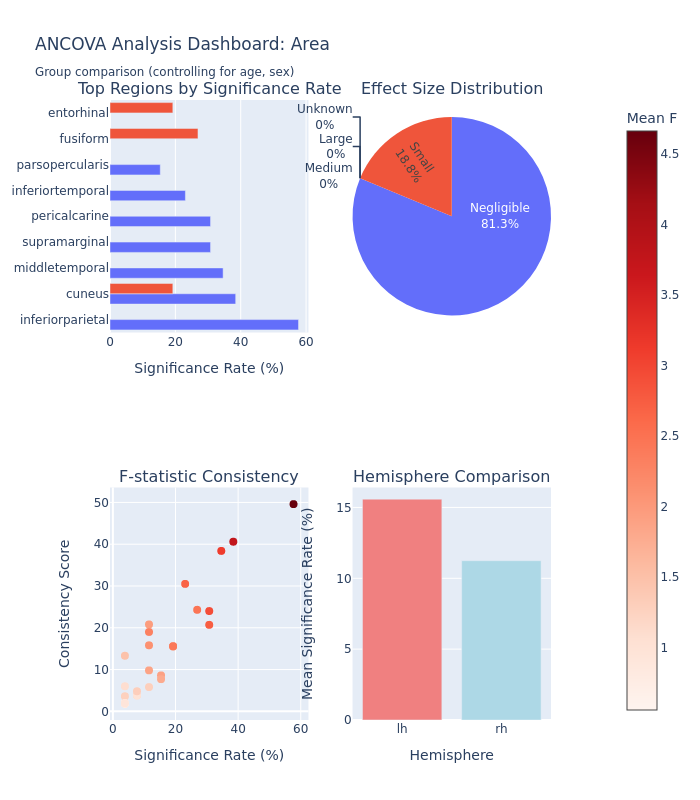


📋 Displaying top results table for area...


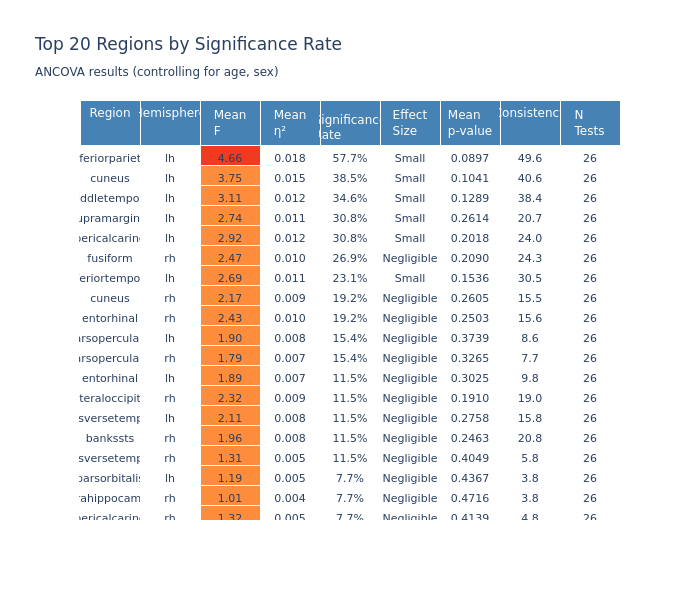


📝 Generating report for area...
📁 Report saved to ancova/reports/area_ancova_longitudinal_report.txt
✅ Report saved to ancova/reports/area_ancova_longitudinal_report.txt

📊 QUICK SUMMARY FOR AREA
------------------------------
Regions analyzed: 32
Significant regions: 32
Mean significance rate: 13.8%
Median F-statistic: 1.40
Top region: inferiorparietal (lh) (57.7%)

🎉 ANALYSIS COMPLETE!
--------------------
✅ Successfully analyzed 1 / 1 metrics
📁 Results saved in ancova/ directory
🎨 Interactive visualizations created and displayed
📝 Detailed reports generated


In [63]:
# Enhanced single metric analysis
area_results = run_complete_ancova_analysis(
    metrics="area",
    cohort_df=df_cohort,
    hemisphere=True,
    alpha=0.05,
    correction_method=None,
    force=False,
)

# Access results
significance_area_df = area_results["area"]["significance_df"]
summary_area = area_results["area"]["summary"]
visualizations_area = area_results["area"]["visualizations"]


In [64]:
significance_area_df

,region,hemisphere,n_significant,proportion_significant,n_correlations,mean_F,std_F,min_F,max_F,mean_p,...,mean_np2,std_np2,min_np2,max_np2,mean_n,min_n,max_n,effect_size_category,significance_rate,correlation_consistency
20,inferiorparietal,lh,15,0.576923,26,4.661766,2.729884,0.380294,9.568907,0.089672,...,0.018269,0.010526,1.524956e-03,0.037007,254.0,254,254,Small,57.692308,49.6
10,cuneus,lh,10,0.384615,26,3.753092,2.145904,0.793270,8.217923,0.104069,...,0.014781,0.008326,3.175705e-03,0.031949,254.0,254,254,Small,38.461538,40.6
36,middletemporal,lh,9,0.346154,26,3.110835,1.799267,0.674098,8.454405,0.128888,...,0.012291,0.007003,2.699912e-03,0.032838,254.0,254,254,Small,34.615385,38.4
68,supramarginal,lh,8,0.307692,26,2.741177,2.447396,0.004305,8.237106,0.261350,...,0.010800,0.009558,1.728983e-05,0.032021,254.0,254,254,Small,30.769231,20.7
48,pericalcarine,lh,8,0.307692,26,2.923627,2.417691,0.052215,9.088386,0.201798,...,0.011518,0.009403,2.096536e-04,0.035214,254.0,254,254,Small,30.769231,24.0
19,fusiform,rh,7,0.269231,26,2.474460,1.940117,0.137134,8.229775,0.209021,...,0.009784,0.007575,5.504377e-04,0.031994,254.0,254,254,Negligible,26.923077,24.3
22,inferiortemporal,lh,6,0.230769,26,2.693680,1.670518,0.897549,7.976090,0.153613,...,0.010661,0.006513,3.591667e-03,0.031038,254.0,254,254,Small,23.076923,30.5
11,cuneus,rh,5,0.192308,26,2.166293,1.909612,0.040500,6.643878,0.260519,...,0.008570,0.007479,1.626250e-04,0.025989,254.0,254,254,Negligible,19.230769,15.5
15,entorhinal,rh,5,0.192308,26,2.429814,2.137653,0.083648,7.737651,0.250317,...,0.009596,0.008350,3.358245e-04,0.030138,254.0,254,254,Negligible,19.230769,15.6
42,parsopercularis,lh,4,0.153846,26,1.903676,1.868562,0.000102,6.905167,0.373944,...,0.007535,0.007349,4.100076e-07,0.026983,254.0,254,254,Negligible,15.384615,8.6


## Subcortical volume


🧠 COMPLETE ANCOVA ANALYSIS
📊 Analyzing 1 metric(s): subcortical_volume
🎯 Significance threshold: α = 0.05
🔧 Multiple comparison correction: None
🌐 Hemisphere analysis: Disabled

🔬 ANALYSIS 1/1: SUBCORTICAL_VOLUME
----------------------------------------

🧠 Enhanced ANCOVA Analysis for SUBCORTICAL_VOLUME

📊 Step 1: Loading baseline data for subcortical_volume...
📁 Loading cached baseline data for subcortical_volume...
Loading next visit data for subcortical_volume...
📁 Loading cached baseline data for subcortical_volume...
✅ Merged baseline and next visit data with shape: (422656, 19)
✅ Computed change for subcortical_volume with shape: (422656, 20)
🔄 Renaming columns for clarity...
✅ Loaded 422656 baseline records

🧮 Step 2: Computing ANCOVA...
📁 Loading cached ANCOVA results for subcortical_volume...
✅ Computed 1479 ANCOVA tests

📊 Step 3: Computing significance statistics...
📊 Computing significance statistics for 1479 ANCOVA tests...
🔄 Adding significance indicators...
🔄 Categorizi

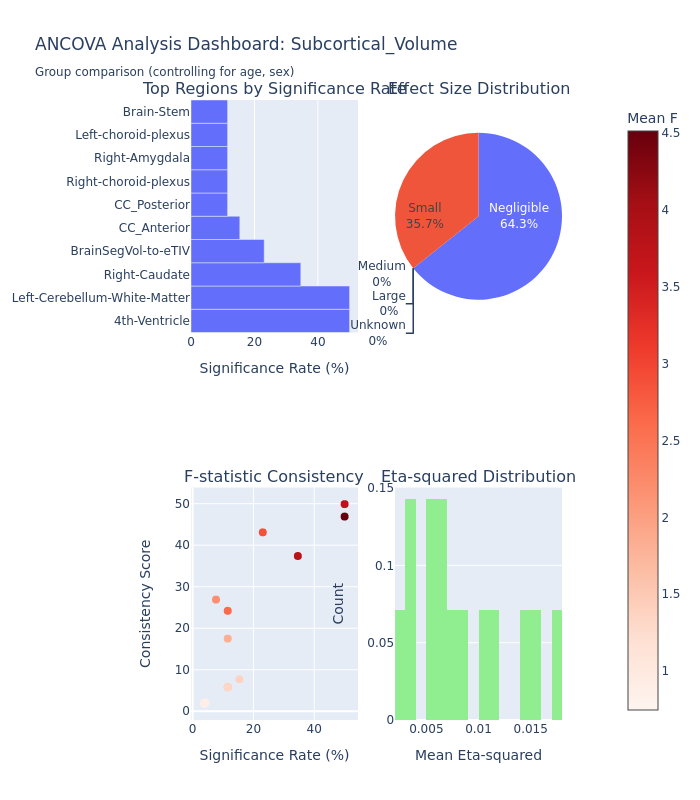


📋 Displaying top results table for subcortical_volume...


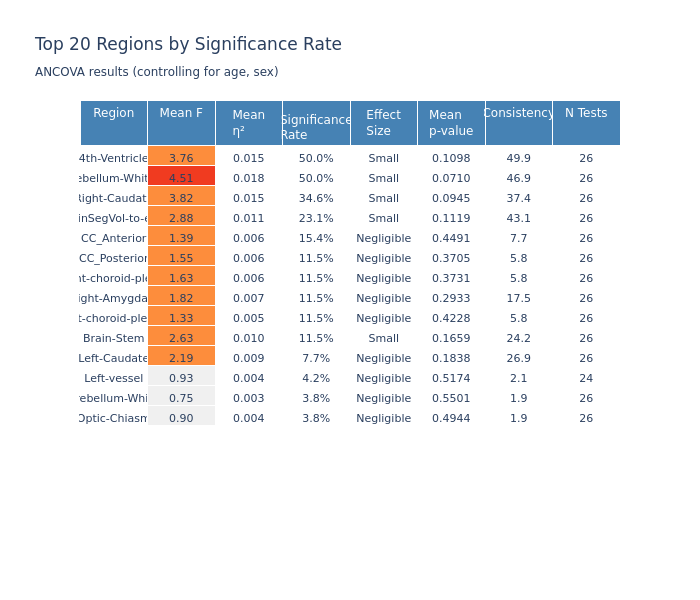


📝 Generating report for subcortical_volume...
📁 Report saved to ancova/reports/subcortical_volume_ancova_longitudinal_report.txt
✅ Report saved to ancova/reports/subcortical_volume_ancova_longitudinal_report.txt

📊 QUICK SUMMARY FOR SUBCORTICAL_VOLUME
------------------------------
Regions analyzed: 14
Significant regions: 14
Mean significance rate: 17.9%
Median F-statistic: 1.72
Top region: 4th-Ventricle (50.0%)

🎉 ANALYSIS COMPLETE!
--------------------
✅ Successfully analyzed 1 / 1 metrics
📁 Results saved in ancova/ directory
🎨 Interactive visualizations created and displayed
📝 Detailed reports generated


In [65]:
# Enhanced single metric analysis
subcortical_volume_results = run_complete_ancova_analysis(
    metrics="subcortical_volume",
    cohort_df=df_cohort,
    hemisphere=False,
    alpha=0.05,
    correction_method=None,
    force=False,
)

# Access results
significance_subcortical_volume_df = subcortical_volume_results["subcortical_volume"][
    "significance_df"
]
summary_subcortical_volume = subcortical_volume_results["subcortical_volume"]["summary"]
visualizations_subcortical_volume = subcortical_volume_results["subcortical_volume"][
    "visualizations"
]


In [67]:
significance_subcortical_volume_df


,region,n_significant,proportion_significant,n_correlations,mean_F,std_F,min_F,max_F,mean_p,std_p,...,mean_np2,std_np2,min_np2,max_np2,mean_n,min_n,max_n,effect_size_category,significance_rate,correlation_consistency
1,4th-Ventricle,13,0.500000,26,3.757400,1.883604,0.053536,8.178769,0.109772,0.163403,...,0.014813,0.007336,2.149571e-04,0.031802,254.000000,254,254,Small,50.000000,49.9
19,Left-Cerebellum-White-Matter,13,0.500000,26,4.512611,2.538237,1.368061,9.960345,0.071026,0.066988,...,0.017706,0.009752,5.464199e-03,0.038463,254.000000,254,254,Small,50.000000,46.9
34,Right-Caudate,9,0.346154,26,3.823122,2.286467,0.869562,10.061319,0.094472,0.086833,...,0.015045,0.008806,3.480064e-03,0.038838,254.000000,254,254,Small,34.615385,37.4
4,BrainSegVol-to-eTIV,6,0.230769,26,2.877448,1.063184,1.066545,5.097426,0.111858,0.066530,...,0.011407,0.004166,4.265044e-03,0.020061,254.000000,254,254,Small,23.076923,43.1
6,CC_Anterior,4,0.153846,26,1.394249,1.692152,0.000132,5.390055,0.449118,0.319126,...,0.005525,0.006671,5.304276e-07,0.021188,254.000000,254,254,Negligible,15.384615,7.7
10,CC_Posterior,3,0.115385,26,1.551022,1.711357,0.026077,5.922375,0.370499,0.257674,...,0.006146,0.006729,1.047141e-04,0.023232,254.000000,254,254,Negligible,11.538462,5.8
44,Right-choroid-plexus,3,0.115385,26,1.626204,2.252202,0.004517,7.877380,0.373071,0.233759,...,0.006413,0.008764,1.814213e-05,0.030666,254.000000,254,254,Negligible,11.538462,5.8
33,Right-Amygdala,3,0.115385,26,1.821123,1.394176,0.023626,6.042853,0.293296,0.272732,...,0.007231,0.005486,9.487503e-05,0.023693,254.000000,254,254,Negligible,11.538462,17.5
27,Left-choroid-plexus,3,0.115385,26,1.333980,1.512375,0.000735,5.871994,0.422823,0.300653,...,0.005294,0.005959,2.953692e-06,0.023039,254.000000,254,254,Negligible,11.538462,5.8
2,Brain-Stem,3,0.115385,26,2.630152,1.661054,0.300913,7.680555,0.165904,0.142864,...,0.010411,0.006480,1.207028e-03,0.029923,254.000000,254,254,Small,11.538462,24.2
